In [1]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, countDistinct, when, isnan, desc, avg, min, max,
    explode, split, lower, from_unixtime, year, to_date, datediff,
    expr, stddev, approx_count_distinct
)

os.makedirs("/workspace/outputs/figures", exist_ok=True)
os.makedirs("/workspace/outputs/metrics", exist_ok=True)
os.makedirs("/workspace/outputs/tables", exist_ok=True)

try:
    spark.stop()
except Exception:
    pass

spark = (
    SparkSession.builder
    .appName("3_EDA_MovieLens_Spark")
    .master("spark://spark-master:7077")
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:8020")
    .config("spark.driver.host", "notebook")
    .config("spark.driver.bindAddress", "0.0.0.0")
    .config("spark.driver.memory", "1g")
    .config("spark.executor.memory", "1g")
    .config("spark.executor.cores", "1")
    .config("spark.cores.max", "1")
    .config("spark.executor.instances", "1")
    .config("spark.sql.shuffle.partitions", "16")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

HDFS_RAW = "hdfs://namenode:8020/netflix-recsys/raw/ml-25m"

df_ratings = spark.read.parquet(f"{HDFS_RAW}/ratings")
df_movies = spark.read.parquet(f"{HDFS_RAW}/movies")
df_tags = spark.read.parquet(f"{HDFS_RAW}/tags")
df_links = spark.read.parquet(f"{HDFS_RAW}/links")
df_genome_scores = spark.read.parquet(f"{HDFS_RAW}/genome_scores")
df_genome_tags = spark.read.parquet(f"{HDFS_RAW}/genome_tags")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/06 09:49:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

In [2]:
dataset_rows = [
    {"dataset": "ratings", "description": "Rating gốc user-movie", "rows": df_ratings.count(), "columns": len(df_ratings.columns)},
    {"dataset": "movies", "description": "Thông tin phim và thể loại", "rows": df_movies.count(), "columns": len(df_movies.columns)},
    {"dataset": "tags", "description": "Tag tự do do người dùng gắn", "rows": df_tags.count(), "columns": len(df_tags.columns)},
    {"dataset": "links", "description": "Mã liên kết IMDb/TMDb", "rows": df_links.count(), "columns": len(df_links.columns)},
    {"dataset": "genome_scores", "description": "Ma trận movie-tag genome dạng movieId, tagId, relevance", "rows": df_genome_scores.count(), "columns": len(df_genome_scores.columns)},
    {"dataset": "genome_tags", "description": "Từ điển tag genome", "rows": df_genome_tags.count(), "columns": len(df_genome_tags.columns)},
]

dataset_overview_df = pd.DataFrame(dataset_rows)
dataset_overview_df.to_csv("/workspace/outputs/tables/dataset_overview.csv", index=False)

with open("/workspace/outputs/metrics/dataset_overview.json", "w", encoding="utf-8") as f:
    json.dump(dataset_rows, f, ensure_ascii=False, indent=2)

dataset_overview_df

,dataset,description,rows,columns
0,ratings,Rating gốc user-movie,25000095,4
1,movies,Thông tin phim và thể loại,62423,3
2,tags,Tag tự do do người dùng gắn,1093360,4
3,links,Mã liên kết IMDb/TMDb,62423,3
4,genome_scores,"Ma trận movie-tag genome dạng movieId, tagId, ...",15584448,3
5,genome_tags,Từ điển tag genome,1128,2


In [3]:
def null_count_expr(df, column_name):
    dtype = dict(df.dtypes)[column_name]
    if dtype in ["double", "float"]:
        return count(when(col(column_name).isNull() | isnan(col(column_name)), column_name)).alias(column_name)
    return count(when(col(column_name).isNull(), column_name)).alias(column_name)

null_tables = {
    "ratings": df_ratings.select([null_count_expr(df_ratings, c) for c in df_ratings.columns]).toPandas(),
    "movies": df_movies.select([null_count_expr(df_movies, c) for c in df_movies.columns]).toPandas(),
    "tags": df_tags.select([null_count_expr(df_tags, c) for c in df_tags.columns]).toPandas(),
    "links": df_links.select([null_count_expr(df_links, c) for c in df_links.columns]).toPandas(),
    "genome_scores": df_genome_scores.select([null_count_expr(df_genome_scores, c) for c in df_genome_scores.columns]).toPandas(),
    "genome_tags": df_genome_tags.select([null_count_expr(df_genome_tags, c) for c in df_genome_tags.columns]).toPandas(),
}

null_summary = {}
for name, table in null_tables.items():
    table.to_csv(f"/workspace/outputs/tables/{name}_null_counts.csv", index=False)
    null_summary[name] = table.to_dict(orient="records")[0]

with open("/workspace/outputs/metrics/null_summary.json", "w", encoding="utf-8") as f:
    json.dump(null_summary, f, ensure_ascii=False, indent=2)

null_summary

{'ratings': {'userId': 0, 'movieId': 0, 'rating': 0, 'timestamp': 0},
 'movies': {'movieId': 0, 'title': 0, 'genres': 0},
 'tags': {'userId': 0, 'movieId': 0, 'tag': 0, 'timestamp': 2},
 'links': {'movieId': 0, 'imdbId': 0, 'tmdbId': 107},
 'genome_scores': {'movieId': 0, 'tagId': 0, 'relevance': 0},
 'genome_tags': {'tagId': 0, 'tag': 0}}

In [4]:
orphan_ratings = df_ratings.join(df_movies.select("movieId"), on="movieId", how="left_anti")
orphan_tags = df_tags.join(df_movies.select("movieId"), on="movieId", how="left_anti")
orphan_genome_scores_movies = df_genome_scores.join(df_movies.select("movieId"), on="movieId", how="left_anti")
orphan_genome_scores_tags = df_genome_scores.join(df_genome_tags.select("tagId"), on="tagId", how="left_anti")
invalid_ratings = df_ratings.filter((col("rating") < 0.5) | (col("rating") > 5.0))
invalid_relevance = df_genome_scores.filter((col("relevance") < 0.0) | (col("relevance") > 1.0))

duplicate_ratings = (
    df_ratings.groupBy("userId", "movieId", "timestamp")
    .agg(count("*").alias("n"))
    .filter(col("n") > 1)
)

data_quality = {
    "orphan_rating_rows": orphan_ratings.count(),
    "orphan_tag_rows": orphan_tags.count(),
    "orphan_genome_score_movie_rows": orphan_genome_scores_movies.count(),
    "orphan_genome_score_tag_rows": orphan_genome_scores_tags.count(),
    "invalid_rating_rows": invalid_ratings.count(),
    "invalid_genome_relevance_rows": invalid_relevance.count(),
    "duplicate_rating_keys": duplicate_ratings.count(),
}

pd.DataFrame([data_quality]).to_csv("/workspace/outputs/tables/data_quality_metrics.csv", index=False)
with open("/workspace/outputs/metrics/data_quality_metrics.json", "w", encoding="utf-8") as f:
    json.dump(data_quality, f, ensure_ascii=False, indent=2)

data_quality

{'orphan_rating_rows': 0,
 'orphan_tag_rows': 0,
 'orphan_genome_score_movie_rows': 0,
 'orphan_genome_score_tag_rows': 0,
 'invalid_rating_rows': 0,
 'invalid_genome_relevance_rows': 0,
 'duplicate_rating_keys': 0}

In [5]:
num_ratings = df_ratings.count()
num_users = df_ratings.select("userId").distinct().count()
num_movies_total = df_movies.select("movieId").distinct().count()
num_movies_rated = df_ratings.select("movieId").distinct().count()
num_movies_with_genome = df_genome_scores.select("movieId").distinct().count()
num_genome_tags = df_genome_tags.select("tagId").distinct().count()

sparsity = 1.0 - (num_ratings / (num_users * num_movies_total))
genome_matrix_coverage = num_movies_with_genome / num_movies_total

sparsity_metrics = {
    "num_users": num_users,
    "num_movies_total": num_movies_total,
    "num_movies_rated": num_movies_rated,
    "num_ratings": num_ratings,
    "user_item_matrix_size": num_users * num_movies_total,
    "sparsity": sparsity,
    "sparsity_percent": sparsity * 100,
    "num_movies_with_genome": num_movies_with_genome,
    "num_genome_tags": num_genome_tags,
    "genome_movie_coverage": genome_matrix_coverage,
    "genome_movie_coverage_percent": genome_matrix_coverage * 100,
}

pd.DataFrame([sparsity_metrics]).to_csv("/workspace/outputs/tables/sparsity_metrics.csv", index=False)
with open("/workspace/outputs/metrics/sparsity_metrics.json", "w", encoding="utf-8") as f:
    json.dump(sparsity_metrics, f, ensure_ascii=False, indent=2)

sparsity_metrics

{'num_users': 162541,
 'num_movies_total': 62423,
 'num_movies_rated': 59047,
 'num_ratings': 25000095,
 'user_item_matrix_size': 10146296843,
 'sparsity': 0.9975360374935958,
 'sparsity_percent': 99.75360374935957,
 'num_movies_with_genome': 13816,
 'num_genome_tags': 1128,
 'genome_movie_coverage': 0.22132867692997774,
 'genome_movie_coverage_percent': 22.132867692997774}

In [6]:
rating_stats = (
    df_ratings
    .select(
        count("*").alias("count"),
        avg("rating").alias("mean_rating"),
        stddev("rating").alias("std_rating"),
        min("rating").alias("min_rating"),
        expr("percentile_approx(rating, 0.25)").alias("q1_rating"),
        expr("percentile_approx(rating, 0.50)").alias("median_rating"),
        expr("percentile_approx(rating, 0.75)").alias("q3_rating"),
        max("rating").alias("max_rating")
    )
    .toPandas()
)

rating_stats.to_csv("/workspace/outputs/tables/rating_descriptive_statistics.csv", index=False)
rating_stats

,count,mean_rating,std_rating,min_rating,q1_rating,median_rating,q3_rating,max_rating
0,25000095,3.533854,1.060744,0.5,3.0,3.5,4.0,5.0


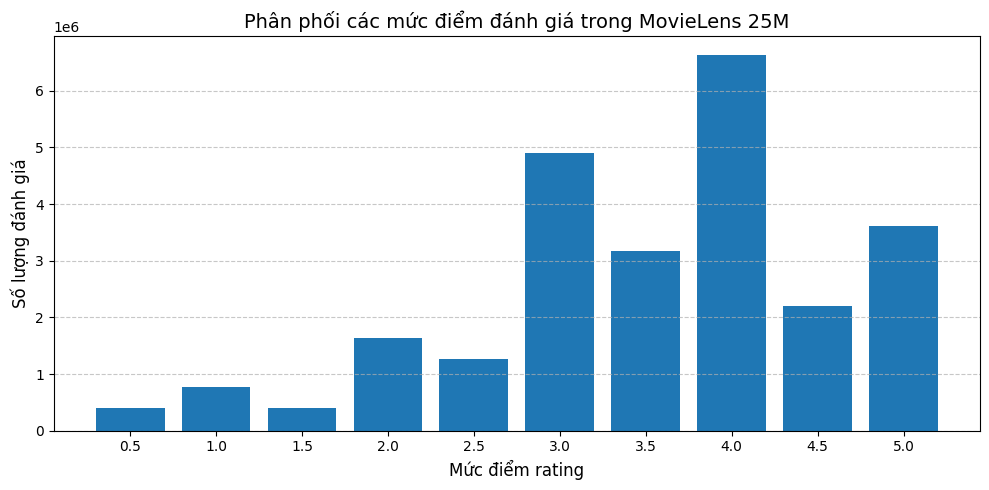

In [7]:
rating_dist_df = (
    df_ratings.groupBy("rating")
    .agg(count("*").alias("count"))
    .orderBy("rating")
    .toPandas()
)

rating_dist_df.to_csv("/workspace/outputs/tables/rating_distribution.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(rating_dist_df["rating"].astype(str), rating_dist_df["count"])
plt.title("Phân phối các mức điểm đánh giá trong MovieLens 25M", fontsize=14)
plt.xlabel("Mức điểm rating", fontsize=12)
plt.ylabel("Số lượng đánh giá", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/rating_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

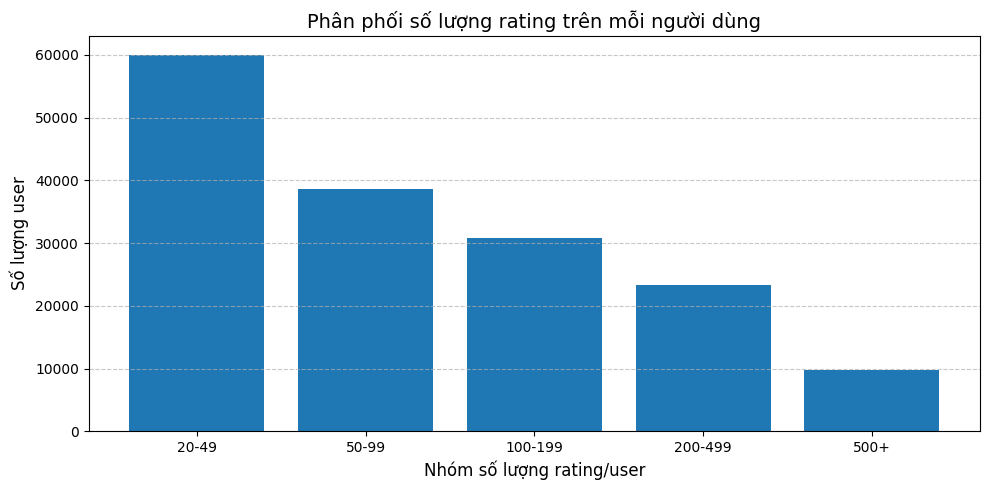

,num_users,avg_ratings_per_user,std_ratings_per_user,min_ratings_per_user,q1_ratings_per_user,median_ratings_per_user,q3_ratings_per_user,max_ratings_per_user
0,162541,153.807932,268.04759,20,36,71,162,32202


In [8]:
user_activity = df_ratings.groupBy("userId").agg(count("*").alias("num_ratings")).cache()

user_activity_stats = (
    user_activity
    .select(
        count("*").alias("num_users"),
        avg("num_ratings").alias("avg_ratings_per_user"),
        stddev("num_ratings").alias("std_ratings_per_user"),
        min("num_ratings").alias("min_ratings_per_user"),
        expr("percentile_approx(num_ratings, 0.25)").alias("q1_ratings_per_user"),
        expr("percentile_approx(num_ratings, 0.50)").alias("median_ratings_per_user"),
        expr("percentile_approx(num_ratings, 0.75)").alias("q3_ratings_per_user"),
        max("num_ratings").alias("max_ratings_per_user")
    )
    .toPandas()
)

user_activity_stats.to_csv("/workspace/outputs/tables/user_activity_statistics.csv", index=False)

user_activity_plot = (
    user_activity
    .withColumn(
        "rating_group",
        when(col("num_ratings") < 20, "<20")
        .when(col("num_ratings") < 50, "20-49")
        .when(col("num_ratings") < 100, "50-99")
        .when(col("num_ratings") < 200, "100-199")
        .when(col("num_ratings") < 500, "200-499")
        .otherwise("500+")
    )
    .groupBy("rating_group")
    .agg(count("*").alias("count"))
    .toPandas()
)

order = ["<20", "20-49", "50-99", "100-199", "200-499", "500+"]
user_activity_plot["rating_group"] = pd.Categorical(user_activity_plot["rating_group"], categories=order, ordered=True)
user_activity_plot = user_activity_plot.sort_values("rating_group")
user_activity_plot.to_csv("/workspace/outputs/tables/user_activity_distribution.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(user_activity_plot["rating_group"].astype(str), user_activity_plot["count"])
plt.title("Phân phối số lượng rating trên mỗi người dùng", fontsize=14)
plt.xlabel("Nhóm số lượng rating/user", fontsize=12)
plt.ylabel("Số lượng user", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/ratings_per_user_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

user_activity_stats

In [9]:
movie_activity = (
    df_ratings
    .groupBy("movieId")
    .agg(count("*").alias("num_ratings"), avg("rating").alias("avg_rating"))
    .cache()
)

movie_activity_stats = (
    movie_activity
    .select(
        count("*").alias("num_movies_rated"),
        avg("num_ratings").alias("avg_ratings_per_movie"),
        stddev("num_ratings").alias("std_ratings_per_movie"),
        min("num_ratings").alias("min_ratings_per_movie"),
        expr("percentile_approx(num_ratings, 0.25)").alias("q1_ratings_per_movie"),
        expr("percentile_approx(num_ratings, 0.50)").alias("median_ratings_per_movie"),
        expr("percentile_approx(num_ratings, 0.75)").alias("q3_ratings_per_movie"),
        max("num_ratings").alias("max_ratings_per_movie")
    )
    .toPandas()
)

movie_activity_stats.to_csv("/workspace/outputs/tables/movie_activity_statistics.csv", index=False)
movie_activity_stats

,num_movies_rated,avg_ratings_per_movie,std_ratings_per_movie,min_ratings_per_movie,q1_ratings_per_movie,median_ratings_per_movie,q3_ratings_per_movie,max_ratings_per_movie
0,59047,423.393144,2477.885821,1,2,6,36,81491


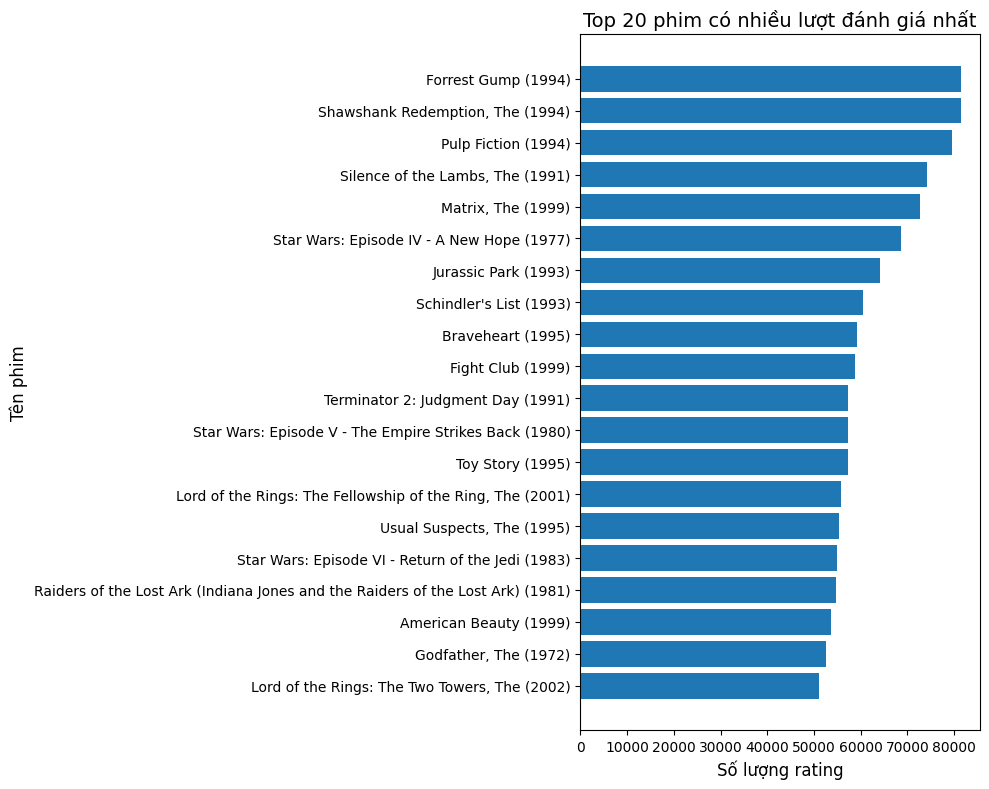

,movieId,num_ratings,avg_rating,title,genres
0,356,81491,4.048011,Forrest Gump (1994),Comedy|Drama|Romance|War
1,318,81482,4.413576,"Shawshank Redemption, The (1994)",Crime|Drama
2,296,79672,4.188912,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
3,593,74127,4.151342,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
4,2571,72674,4.154099,"Matrix, The (1999)",Action|Sci-Fi|Thriller
5,260,68717,4.120189,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
6,480,64144,3.679175,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
7,527,60411,4.247579,Schindler's List (1993),Drama|War
8,110,59184,4.002273,Braveheart (1995),Action|Drama|War
9,2959,58773,4.228311,Fight Club (1999),Action|Crime|Drama|Thriller


In [10]:
top_movies_by_count = (
    movie_activity
    .join(df_movies, "movieId", "left")
    .orderBy(desc("num_ratings"))
    .limit(20)
    .toPandas()
)

top_movies_by_count.to_csv("/workspace/outputs/tables/top_20_movies_by_rating_count.csv", index=False)
plot_df = top_movies_by_count.sort_values("num_ratings")

plt.figure(figsize=(10, 8))
plt.barh(plot_df["title"], plot_df["num_ratings"])
plt.title("Top 20 phim có nhiều lượt đánh giá nhất", fontsize=14)
plt.xlabel("Số lượng rating", fontsize=12)
plt.ylabel("Tên phim", fontsize=12)
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/top_20_movies_by_rating_count.png", dpi=200, bbox_inches="tight")
plt.show()

top_movies_by_count

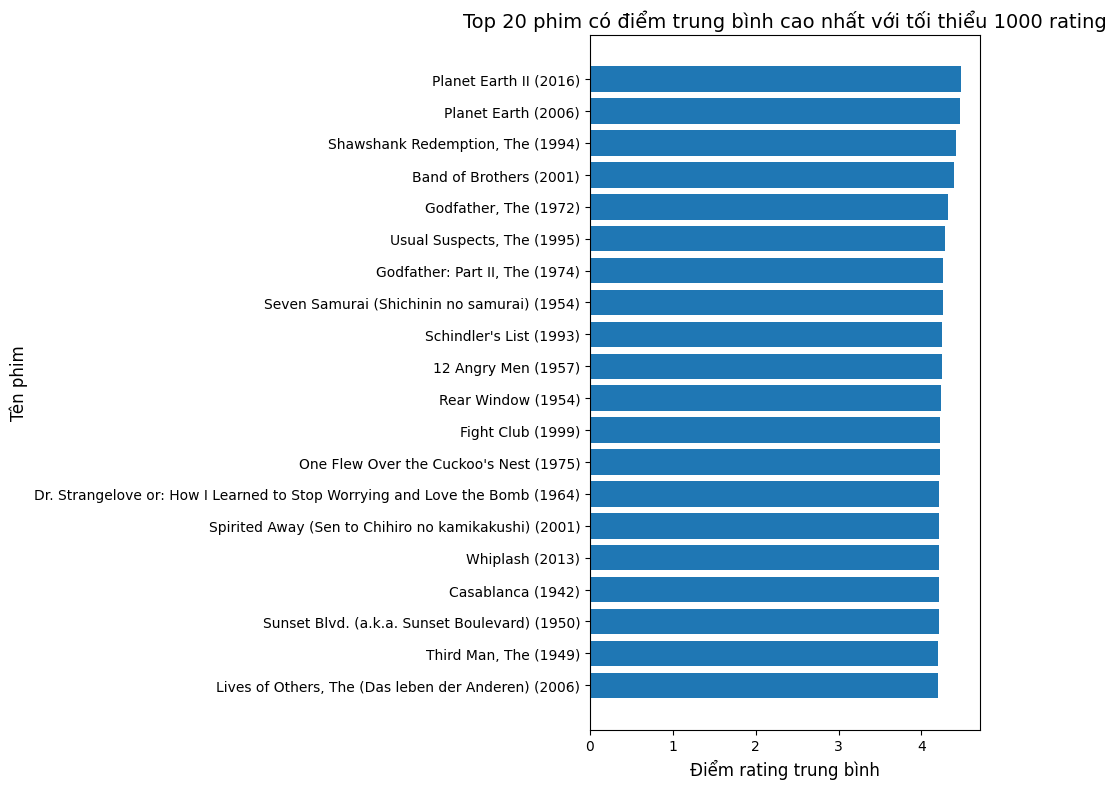

,movieId,num_ratings,avg_rating,title,genres
0,171011,1124,4.483096,Planet Earth II (2016),Documentary
1,159817,1747,4.464797,Planet Earth (2006),Documentary
2,318,81482,4.413576,"Shawshank Redemption, The (1994)",Crime|Drama
3,170705,1356,4.398599,Band of Brothers (2001),Action|Drama|War
4,858,52498,4.324336,"Godfather, The (1972)",Crime|Drama
5,50,55366,4.284353,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
6,1221,34188,4.261759,"Godfather: Part II, The (1974)",Crime|Drama
7,2019,13367,4.254769,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama
8,527,60411,4.247579,Schindler's List (1993),Drama|War
9,1203,16569,4.243014,12 Angry Men (1957),Drama


In [11]:
top_movies_by_avg_rating = (
    movie_activity
    .filter(col("num_ratings") >= 1000)
    .join(df_movies, "movieId", "left")
    .orderBy(desc("avg_rating"))
    .limit(20)
    .toPandas()
)

top_movies_by_avg_rating.to_csv("/workspace/outputs/tables/top_20_movies_by_avg_rating.csv", index=False)
plot_df = top_movies_by_avg_rating.sort_values("avg_rating")

plt.figure(figsize=(10, 8))
plt.barh(plot_df["title"], plot_df["avg_rating"])
plt.title("Top 20 phim có điểm trung bình cao nhất với tối thiểu 1000 rating", fontsize=14)
plt.xlabel("Điểm rating trung bình", fontsize=12)
plt.ylabel("Tên phim", fontsize=12)
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/top_20_movies_by_avg_rating.png", dpi=200, bbox_inches="tight")
plt.show()

top_movies_by_avg_rating

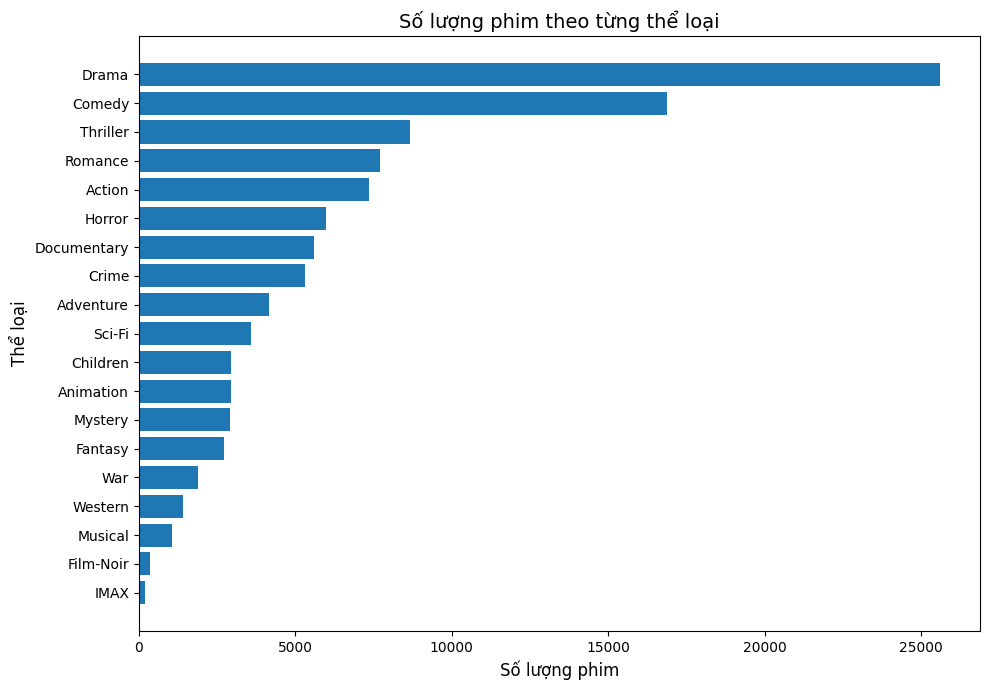

,genre,count
0,Drama,25606
1,Comedy,16870
2,Thriller,8654
3,Romance,7719
4,Action,7348
5,Horror,5989
6,Documentary,5605
7,Crime,5319
8,Adventure,4145
9,Sci-Fi,3595


In [12]:
genres_df = (
    df_movies
    .withColumn("genre", explode(split(col("genres"), "\\|")))
    .filter(col("genre") != "(no genres listed)")
)

genre_distribution = (
    genres_df.groupBy("genre")
    .agg(count("*").alias("count"))
    .orderBy(desc("count"))
    .toPandas()
)

genre_distribution.to_csv("/workspace/outputs/tables/genre_distribution.csv", index=False)
plot_df = genre_distribution.sort_values("count")

plt.figure(figsize=(10, 7))
plt.barh(plot_df["genre"], plot_df["count"])
plt.title("Số lượng phim theo từng thể loại", fontsize=14)
plt.xlabel("Số lượng phim", fontsize=12)
plt.ylabel("Thể loại", fontsize=12)
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/genre_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

genre_distribution

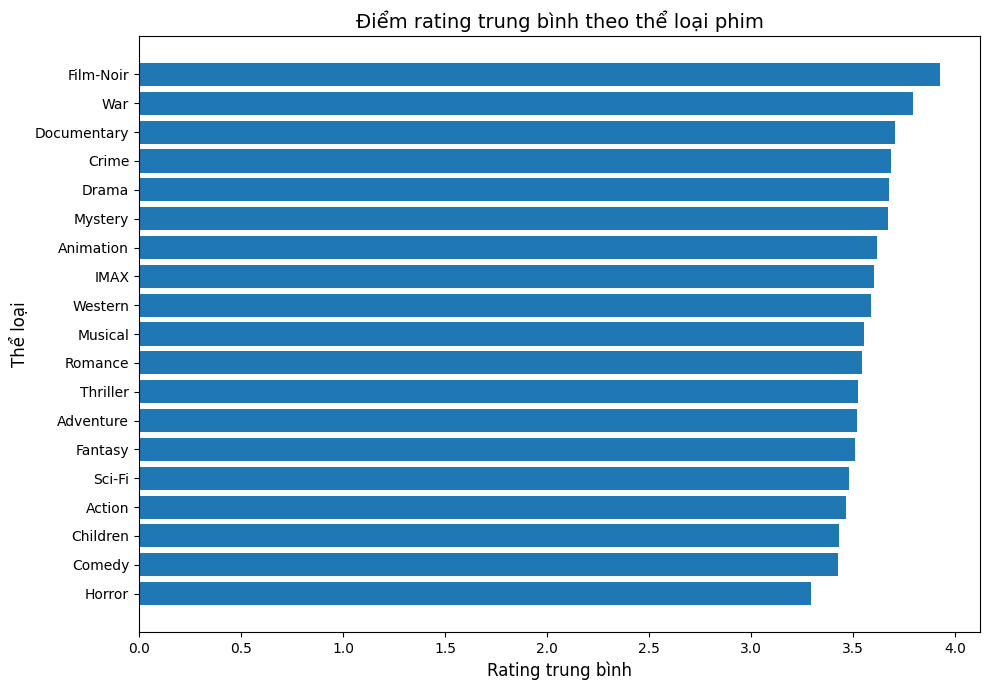

,genre,num_ratings,avg_rating
0,Film-Noir,247227,3.925728
1,War,1267346,3.791466
2,Documentary,322449,3.705281
3,Crime,4190259,3.685044
4,Drama,10962833,3.677185
5,Mystery,2010995,3.670169
6,Animation,1630987,3.614946
7,IMAX,1063279,3.603712
8,Western,483731,3.585755
9,Musical,964252,3.554716


In [13]:
genre_rating = (
    df_ratings
    .join(genres_df.select("movieId", "genre"), "movieId", "inner")
    .groupBy("genre")
    .agg(count("*").alias("num_ratings"), avg("rating").alias("avg_rating"))
    .orderBy(desc("avg_rating"))
    .toPandas()
)

genre_rating.to_csv("/workspace/outputs/tables/genre_rating_statistics.csv", index=False)
plot_df = genre_rating.sort_values("avg_rating")

plt.figure(figsize=(10, 7))
plt.barh(plot_df["genre"], plot_df["avg_rating"])
plt.title("Điểm rating trung bình theo thể loại phim", fontsize=14)
plt.xlabel("Rating trung bình", fontsize=12)
plt.ylabel("Thể loại", fontsize=12)
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/avg_rating_by_genre.png", dpi=200, bbox_inches="tight")
plt.show()

genre_rating

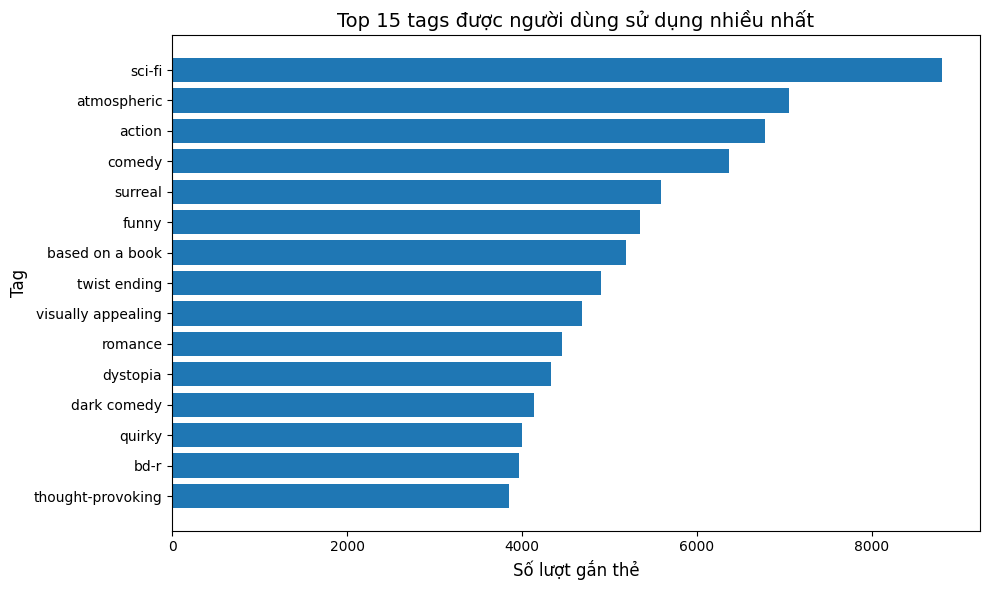

,tag_lower,count
0,sci-fi,8795
1,atmospheric,7053
2,action,6783
3,comedy,6366
4,surreal,5584
5,funny,5354
6,based on a book,5194
7,twist ending,4904
8,visually appealing,4691
9,romance,4458


In [14]:
top_tags_df = (
    df_tags
    .filter(col("tag").isNotNull())
    .withColumn("tag_lower", lower(col("tag")))
    .groupBy("tag_lower")
    .agg(count("*").alias("count"))
    .orderBy(desc("count"))
    .limit(15)
    .toPandas()
)

top_tags_df.to_csv("/workspace/outputs/tables/top_15_user_tags.csv", index=False)
plot_df = top_tags_df.sort_values("count")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["tag_lower"], plot_df["count"])
plt.title("Top 15 tags được người dùng sử dụng nhiều nhất", fontsize=14)
plt.xlabel("Số lượt gắn thẻ", fontsize=12)
plt.ylabel("Tag", fontsize=12)
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/top_15_user_tags.png", dpi=200, bbox_inches="tight")
plt.show()

top_tags_df

In [15]:
genome_relevance_stats = (
    df_genome_scores
    .select(
        count("*").alias("count"),
        avg("relevance").alias("mean_relevance"),
        stddev("relevance").alias("std_relevance"),
        min("relevance").alias("min_relevance"),
        expr("percentile_approx(relevance, 0.50)").alias("median_relevance"),
        max("relevance").alias("max_relevance"),
    )
    .toPandas()
)

genome_relevance_stats.to_csv("/workspace/outputs/tables/genome_relevance_statistics.csv", index=False)
genome_relevance_stats

,count,mean_relevance,std_relevance,min_relevance,median_relevance,max_relevance
0,15584448,0.116368,0.154472,0.00025,0.0565,1.0


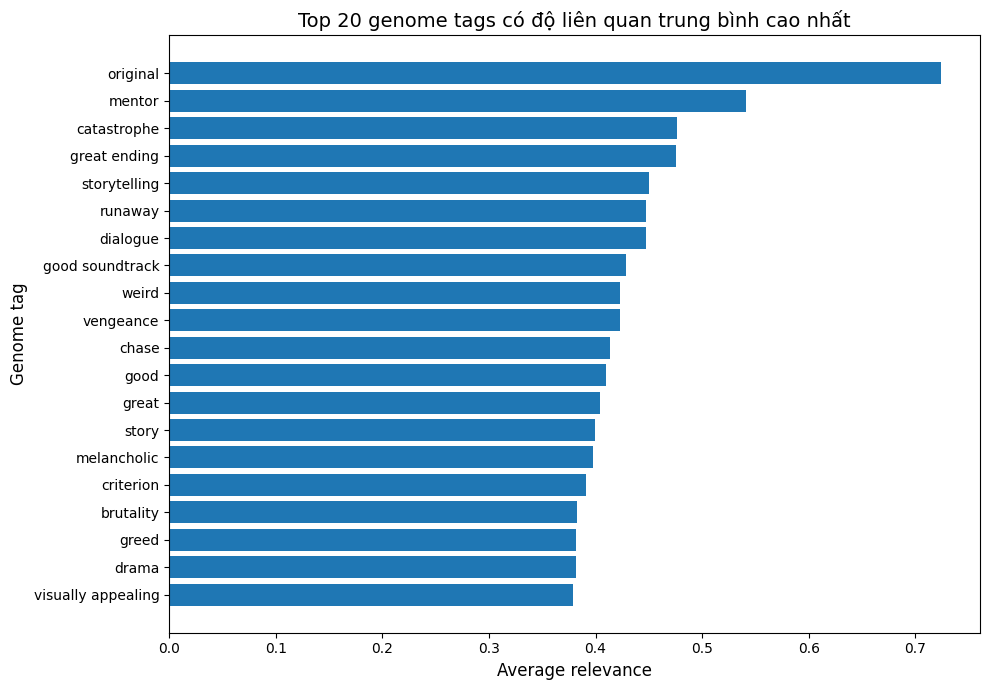

,tagId,avg_relevance,std_relevance,tag
0,742,0.724424,0.093067,original
1,646,0.541578,0.145630,mentor
2,188,0.476752,0.074345,catastrophe
3,468,0.475400,0.143408,great ending
4,972,0.450228,0.173481,storytelling
5,867,0.447721,0.153311,runaway
6,302,0.447113,0.144213,dialogue
7,452,0.428610,0.182151,good soundtrack
8,1104,0.422813,0.208444,weird
9,1070,0.422712,0.156111,vengeance


In [16]:
top_genome_tags = (
    df_genome_scores
    .groupBy("tagId")
    .agg(avg("relevance").alias("avg_relevance"), stddev("relevance").alias("std_relevance"))
    .join(df_genome_tags, "tagId", "left")
    .orderBy(desc("avg_relevance"))
    .limit(20)
    .toPandas()
)

top_genome_tags.to_csv("/workspace/outputs/tables/top_20_genome_tags_by_avg_relevance.csv", index=False)
plot_df = top_genome_tags.sort_values("avg_relevance")

plt.figure(figsize=(10, 7))
plt.barh(plot_df["tag"], plot_df["avg_relevance"])
plt.title("Top 20 genome tags có độ liên quan trung bình cao nhất", fontsize=14)
plt.xlabel("Average relevance", fontsize=12)
plt.ylabel("Genome tag", fontsize=12)
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/top_20_genome_tags_by_avg_relevance.png", dpi=200, bbox_inches="tight")
plt.show()

top_genome_tags

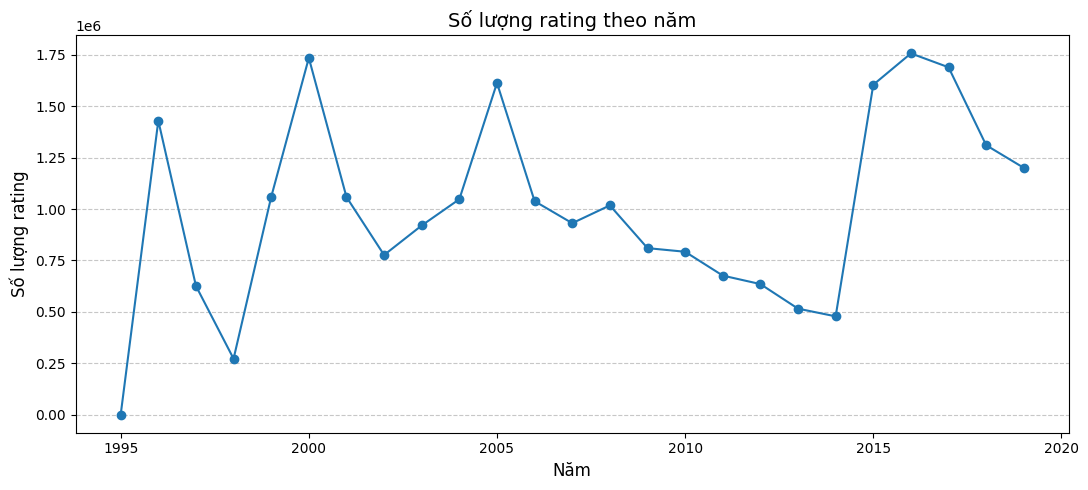

,rating_year,num_ratings
0,1995,3
1,1996,1430093
2,1997,626202
3,1998,272099
4,1999,1059080
5,2000,1735398
6,2001,1058750
7,2002,776654
8,2003,920295
9,2004,1048116


In [17]:
ratings_by_year = (
    df_ratings
    .withColumn("rating_datetime", from_unixtime(col("timestamp")))
    .withColumn("rating_year", year(col("rating_datetime")))
    .groupBy("rating_year")
    .agg(count("*").alias("num_ratings"))
    .orderBy("rating_year")
    .toPandas()
)

ratings_by_year.to_csv("/workspace/outputs/tables/ratings_by_year.csv", index=False)

plt.figure(figsize=(11, 5))
plt.plot(ratings_by_year["rating_year"], ratings_by_year["num_ratings"], marker="o")
plt.title("Số lượng rating theo năm", fontsize=14)
plt.xlabel("Năm", fontsize=12)
plt.ylabel("Số lượng rating", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("/workspace/outputs/figures/ratings_by_year.png", dpi=200, bbox_inches="tight")
plt.show()

ratings_by_year

In [18]:
user_lifetime = (
    df_ratings
    .withColumn("rating_date", to_date(from_unixtime(col("timestamp"))))
    .groupBy("userId")
    .agg(
        count("*").alias("num_ratings"),
        min("rating_date").alias("first_rating_date"),
        max("rating_date").alias("last_rating_date"),
        avg("rating").alias("avg_user_rating")
    )
    .withColumn("active_days", datediff(col("last_rating_date"), col("first_rating_date")))
    .cache()
)

long_term_users = user_lifetime.filter((col("num_ratings") >= 50) & (col("active_days") >= 180))

total_users = user_lifetime.count()
long_term_user_count = long_term_users.count()

long_term_summary = {
    "total_users": total_users,
    "long_term_users": long_term_user_count,
    "long_term_user_ratio": long_term_user_count / total_users,
}

long_term_stats = (
    long_term_users
    .select(
        count("*").alias("num_long_term_users"),
        avg("num_ratings").alias("avg_ratings_per_long_term_user"),
        min("num_ratings").alias("min_ratings_per_long_term_user"),
        expr("percentile_approx(num_ratings, 0.5)").alias("median_ratings_per_long_term_user"),
        max("num_ratings").alias("max_ratings_per_long_term_user"),
        avg("active_days").alias("avg_active_days"),
        min("active_days").alias("min_active_days"),
        max("active_days").alias("max_active_days")
    )
    .toPandas()
)

with open("/workspace/outputs/metrics/long_term_user_summary.json", "w", encoding="utf-8") as f:
    json.dump(long_term_summary, f, ensure_ascii=False, indent=2)

long_term_stats.to_csv("/workspace/outputs/tables/long_term_user_statistics.csv", index=False)
long_term_summary, long_term_stats

({'total_users': 162541,
  'long_term_users': 25945,
  'long_term_user_ratio': 0.1596212647885764},
    num_long_term_users  avg_ratings_per_long_term_user  \
 0                25945                       415.20027   
 
    min_ratings_per_long_term_user  median_ratings_per_long_term_user  \
 0                              50                                268   
 
    max_ratings_per_long_term_user  avg_active_days  min_active_days  \
 0                           32202      1270.177838              180   
 
    max_active_days  
 0             8102  )

In [19]:
eda_final_summary = {
    "dataset_overview": dataset_rows,
    "data_quality": data_quality,
    "sparsity_metrics": sparsity_metrics,
    "long_term_user_summary": long_term_summary,
    "genome_usage_note": "genome_scores and genome_tags are included as movie content features for hybrid NCF in notebooks 6 and 7.",
}

with open("/workspace/outputs/metrics/eda_final_summary.json", "w", encoding="utf-8") as f:
    json.dump(eda_final_summary, f, ensure_ascii=False, indent=2)

eda_final_summary

{'dataset_overview': [{'dataset': 'ratings',
   'description': 'Rating gốc user-movie',
   'rows': 25000095,
   'columns': 4},
  {'dataset': 'movies',
   'description': 'Thông tin phim và thể loại',
   'rows': 62423,
   'columns': 3},
  {'dataset': 'tags',
   'description': 'Tag tự do do người dùng gắn',
   'rows': 1093360,
   'columns': 4},
  {'dataset': 'links',
   'description': 'Mã liên kết IMDb/TMDb',
   'rows': 62423,
   'columns': 3},
  {'dataset': 'genome_scores',
   'description': 'Ma trận movie-tag genome dạng movieId, tagId, relevance',
   'rows': 15584448,
   'columns': 3},
  {'dataset': 'genome_tags',
   'description': 'Từ điển tag genome',
   'rows': 1128,
   'columns': 2}],
 'data_quality': {'orphan_rating_rows': 0,
  'orphan_tag_rows': 0,
  'orphan_genome_score_movie_rows': 0,
  'orphan_genome_score_tag_rows': 0,
  'invalid_rating_rows': 0,
  'invalid_genome_relevance_rows': 0,
  'duplicate_rating_keys': 0},
 'sparsity_metrics': {'num_users': 162541,
  'num_movies_total

In [20]:
spark.stop()